In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime, csv
from matplotlib.colors import LinearSegmentedColormap

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/e2e'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///', '\\\\\\', '+', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [11]:

def extract_optimization_time(log_file_path, csv_file_path):
    # 正则表达式模式
    time_pattern = r"Time is: (\d+\.\d+) ms"
    iteration_pattern = r"iteration: (\d+)"

    # 用于存储结果的列表
    records = []

    # 打开日志文件并读取内容
    with open(log_file_path, 'r') as log_file:
        log_content = log_file.read()

        # 查找所有匹配的Time和iteration
        time_matches = re.findall(time_pattern, log_content)
        iteration_matches = re.findall(iteration_pattern, log_content)

        # 确保Time和iteration的数量一致
        min_length = min(len(time_matches), len(iteration_matches))
        for i in range(min_length):
            record = {
                "Time": time_matches[i],
                "Iteration": iteration_matches[i]
            }
            records.append(record)

    # 将结果写入CSV文件
    with open(csv_file_path, 'w', newline='') as csvfile:
        fieldnames = ["Time", "Iteration"]
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        for record in records:
            writer.writerow(record)

    print(f"数据已成功写入 {csv_file_path}")

In [92]:
# dataset_name = 'sharegpt' 
# num_prompt = 3024
dataset_name = 'paper_assistant' 
num_prompt = 184
model_name = 'meta-llama_Llama-2-13b-chat-hf'
num_gpu = 1
system_name = 'ellm'
input_log = f'{DATASET_PATH}/{system_name}/{dataset_name}/{model_name}_server_{num_prompt}_recompute_{num_gpu}gpu.log'
output_csv = input_log.replace('.log', '_opt_time.csv')
extract_optimization_time(input_log, output_csv)

数据已成功写入 /root/workspace/vllm-dynamic/scripts/dataset/e2e/ellm/paper_assistant/meta-llama_Llama-2-13b-chat-hf_server_184_recompute_1gpu_opt_time.csv


In [116]:
def plot_overhead(csv_paths, data_names, model_size):
    # 绘制优化时间CDF图
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for i, (csv_path, data_name) in enumerate(zip(csv_paths, data_names)):
        df = pd.read_csv(csv_path)
        df['Time'] = df['Time'].astype(float)
        df.sort_values('Time', inplace=True)
        print(f"数据集 {data_name} 的平均优化时间: {df['Time'].mean():.2f} ms")
        cdf = np.arange(len(df)) / float(len(df))
        ax.plot(df['Time'], cdf, label=data_name, color=plt.cm.tab20b(i/4), linestyle=line_styles[i+1])

        # 用垂直线标记平均值的点
        mean_time = df['Time'].mean()
        # ax.axvline(mean_time, color=plt.cm.tab20b(i/4), linestyle='--', linewidth=0.5)
        ax.text(mean_time + 0.2, 0.1+(i+1)*0.2, f'Mean: {mean_time:.2f}', color=plt.cm.tab20b(i/4), fontsize=8)
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('CDF')
    ax.grid(True, axis='y', linestyle='-.', linewidth=0.3, zorder=-10, alpha=0.5)
    ax.legend(loc='best', ncol=1, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/e2e_{model_size}_overhead.pdf')

数据集 ShareGPT 的平均优化时间: 4.58 ms
数据集 L-Eval 的平均优化时间: 2.91 ms


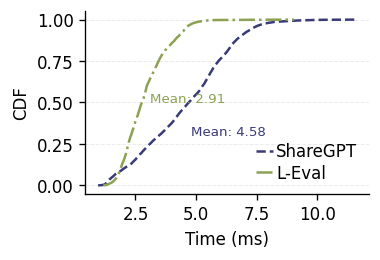

In [117]:
model_name = 'meta-llama_Llama-2-13b-chat-hf'
num_gpu = 1
csv_paths = [
    f'{DATASET_PATH}/{system_name}/sharegpt/{model_name}_server_3024_recompute_{num_gpu}gpu_opt_time.csv',
    f'{DATASET_PATH}/{system_name}/paper_assistant/{model_name}_server_184_recompute_{num_gpu}gpu_opt_time.csv'
]
model_size = '13B'
data_names = ['ShareGPT', 'L-Eval']
plot_overhead(csv_paths, data_names, model_size)

数据集 ShareGPT 的平均优化时间: 6.04 ms
数据集 L-Eval 的平均优化时间: 3.25 ms


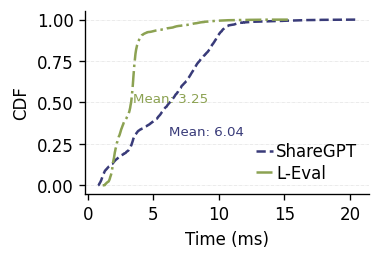

In [118]:
model_name = 'meta-llama_Llama-2-70b-chat-hf'
num_gpu = 4
csv_paths = [
    f'{DATASET_PATH}/{system_name}/sharegpt/{model_name}_server_3024_recompute_{num_gpu}gpu_opt_time.csv',
    f'{DATASET_PATH}/{system_name}/paper_assistant/{model_name}_server_184_recompute_{num_gpu}gpu_opt_time.csv'
]
model_size = '70B'
data_names = ['ShareGPT', 'L-Eval']
plot_overhead(csv_paths, data_names, model_size)